# Bayesian Counterfactual Analysis: HALE Gap

This notebook performs counterfactual analysis for the HALE gap using the Bayesian panel model results. For each gap predictor, we compute what would happen to a country's predicted HALE gap if we adjusted that predictor to the best attainable value observed across all country-years.

## Overview

**Counterfactual Question**: What would happen to a country's HALE gap if we adjusted a specific gap predictor to the best attainable value (while keeping all other predictors constant)?

**Key Features**:
- Uses posterior distributions (not just point estimates) to quantify uncertainty
- Accounts for country-specific intercepts (α_i) when making predictions
- Provides credible intervals (94% HDI) for all counterfactual predictions

In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
from pathlib import Path
import json

from utils import (
    decorate, configure_plot_style, AIBM_COLORS,
    code_to_who_country, codes_to_country_names,
    write_html_table
)
from counterfactual_utils import (
    compute_importance_summary,
    create_counterfactual_visualizations,
    plot_counterfactual_forest,
    plot_counterfactual_by_type,
    plot_counterfactual_bar,
    format_counterfactual_table,
    compute_gap_extremes,
    counterfactual_predictions_bayesian,
    plot_predicted_vs_actual_over_time,
    compute_positive_contributions_over_time,
    plot_positive_contributions_stacked_area,
    plot_positive_contributions_percentage
)

configure_plot_style()

## Load Saved Model Results

In [28]:
# ============================================================================
# MODEL CONFIGURATION: Select which model version to use
# ============================================================================
# Options:
#   '2019_nocovid' - Pre-COVID baseline (2000-2019, no COVID-19 predictor)
#   '2021_covid'   - Extended analysis (2000-2021, includes COVID-19 predictor)
#   'legacy'       - Legacy model (older format, if exists)
MODEL_VERSION = '2019_nocovid'  
MODEL_VERSION = '2021_covid' 

# Map model version to suffix
MODEL_SUFFIX_MAP = {
    '2019_nocovid': '_nomid_nogrw_y2019_nocovid',
    '2021_covid': '_nomid_nogrw_y2021_covid',
    'legacy': '_nomid_nogrw'  # Older format, may not exist
}

# Get the suffix for the selected model version
MODEL_SUFFIX = MODEL_SUFFIX_MAP.get(MODEL_VERSION, '_nomid_nogrw_y2019_nocovid')

print(f"Model Configuration:")
print(f"  Selected version: {MODEL_VERSION}")
print(f"  Model suffix: {MODEL_SUFFIX}")

# Path to saved results
results_dir = Path('../data/bayesian_model_results')

Model Configuration:
  Selected version: 2021_covid
  Model suffix: _nomid_nogrw_y2021_covid


In [29]:
# Load metadata
meta_filename = results_dir / f'metadata_hale{MODEL_SUFFIX}.json'
with open(meta_filename, 'r') as f:
    metadata = json.load(f)

print("Metadata loaded:")
print(f"  Countries: {len(metadata['countries'])}")
print(f"  Years: {len(metadata['years'])} (range: {min(metadata['years'])}-{max(metadata['years'])})")
print(f"  Predictors: {len(metadata['predictors'])}")
print(f"  Model config: {metadata['model_config']}")

Metadata loaded:
  Countries: 37
  Years: 22 (range: 2000-2021)
  Predictors: 12
  Model config: {'mid_predictors_included': [], 'include_year_effects': False, 'countries_excluded': ['TUR'], 'cutoff_year': 2021, 'include_covid_data': True}


In [30]:
# Load trace (posterior samples)
trace_filename = results_dir / f'trace_hale{MODEL_SUFFIX}.nc'
trace = az.from_netcdf(trace_filename)
print(f"\nTrace loaded from: {trace_filename}")
print(f"Number of chains: {trace.posterior.sizes['chain']}")
print(f"Number of draws per chain: {trace.posterior.sizes['draw']}")
print(f"Total samples: {trace.posterior.sizes['chain'] * trace.posterior.sizes['draw']}")


Trace loaded from: ../data/bayesian_model_results/trace_hale_nomid_nogrw_y2021_covid.nc
Number of chains: 4
Number of draws per chain: 1000
Total samples: 4000


In [31]:
# Load panel dataset
panel_filename = results_dir / f'panel_dataset{MODEL_SUFFIX}.h5'
panel_df = pd.read_hdf(panel_filename, key='panel_data')
print(f"\nPanel dataset loaded from: {panel_filename}")
print(f"Shape: {panel_df.shape}")
print(f"Columns: {list(panel_df.columns)[:10]}...")  # Show first 10 columns


Panel dataset loaded from: ../data/bayesian_model_results/panel_dataset_nomid_nogrw_y2021_covid.h5
Shape: (814, 28)
Columns: ['country', 'Year', 'HALE_gap', 'LE_gap', 'Mid_Alcohol', 'Gap_Alcohol', 'Mid_Suicide', 'Gap_Suicide', 'Mid_Homicide', 'Gap_Homicide']...


In [32]:
# Verify data alignment
print("\nData verification:")
print(f"  Panel countries: {panel_df['country'].nunique()}")
print(f"  Metadata countries: {len(metadata['countries'])}")
print(f"  Panel years: {sorted(panel_df['Year'].unique())[:5]}...")  # Show first 5
print(f"  Metadata years: {metadata['years'][:5]}...")  # Show first 5


Data verification:
  Panel countries: 37
  Metadata countries: 37
  Panel years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004)]...
  Metadata years: [2000, 2001, 2002, 2003, 2004]...


## Extract Transformation Parameters

In [33]:
# Extract standardization parameters (convert back to numpy arrays)
X_mean = np.array(metadata['X_mean'])
X_std = np.array(metadata['X_std'])
y_mean = metadata['y_mean']

# Extract predictor names and country/year mappings
predictors = metadata['predictors']
countries = np.array(metadata['countries'])
years = np.array(metadata['years'])

# Create indexers for country and year
country_to_idx = {c: i for i, c in enumerate(countries)}
year_to_idx = {y: i for i, y in enumerate(years)}

print("Transformation parameters:")
print(f"  X_mean shape: {X_mean.shape}")
print(f"  X_std shape: {X_std.shape}")
print(f"  y_mean: {y_mean:.4f} years")
print(f"  Number of predictors: {len(predictors)}")

Transformation parameters:
  X_mean shape: (12,)
  X_std shape: (12,)
  y_mean: 2.6236 years
  Number of predictors: 12


## Gap Extremes Table

Find the minimum and maximum gap values for each gap predictor across all country-years:

In [34]:
# Compute extremes for each gap predictor using helper function
gap_extremes = compute_gap_extremes(panel_df)

# Display as DataFrame
gap_extremes_df = pd.DataFrame(gap_extremes).T
gap_extremes_df = gap_extremes_df.sort_index()
print(f"Found {len(gap_extremes)} gap predictors")
gap_extremes_df

Found 12 gap predictors


,min_gap,min_country,min_year,max_gap,max_country,max_year
Gap_Alcohol,0.232216,COL,2016,33.115885,EST,2005
Gap_COVID,-15.202926,SVN,2020,151.884331,MEX,2020
Gap_Cardiovascular,-191.111845,LVA,2021,38.467765,ISL,2004
Gap_ChronicRespiratory,-19.634566,ISL,2021,44.704105,BEL,2000
Gap_Diabetes,-11.964442,LVA,2021,6.808071,USA,2021
Gap_DrugDisorder,0.002801,JPN,2013,22.474917,USA,2021
Gap_Homicide,-0.062157,NOR,2019,140.488807,COL,2002
Gap_LiverDisease,0.728846,ISL,2001,65.249061,HUN,2000
Gap_Neoplasms,-2.93991,COL,2021,139.183482,PRT,2021
Gap_RoadTraffic,1.916296,ISL,2017,31.35789,LVA,2000


## Counterfactual Prediction Function

The counterfactual prediction function is imported from `counterfactual_utils`. It computes what would happen to a country's predicted gap if we adjusted a specific gap predictor to the best attainable value observed across all country-years.

## Test Counterfactual Function

Test the function with a simple example:

In [35]:
# Test with USA in 2019, Alcohol gap
test_country = 'USA'
test_year = 2019
test_predictor = 'Gap_Alcohol'

result = counterfactual_predictions_bayesian(
    test_country, test_year, test_predictor,
    trace, metadata, panel_df, gap_extremes,
    country_to_idx, year_to_idx
)

print(f"Counterfactual Analysis: {code_to_who_country.get(test_country, test_country)} ({test_country}) in {test_year}")
print(f"Indicator: {result['indicator']}")
print(f"\nCurrent {result['indicator']} gap (predictor): {result['current_gap']:.3f}")
print(f"Note: This is the gap for the {result['indicator']} predictor, not the HALE gap itself")
if result['target_country']:
    print(f"Target gap: {result['target_gap']:.3f} (from {code_to_who_country.get(result['target_country'], result['target_country'])} in {result['target_year']})")
else:
    print(f"Target gap: {result['target_gap']:.3f} (set to zero)")
print(f"\nPredicted HALE gap (original, before counterfactual):")
print(f"  Mean: {result['original_summary']['mean']:.3f} years")
print(f"  94% HDI: [{result['original_summary']['hdi_3%']:.3f}, {result['original_summary']['hdi_97%']:.3f}]")
print(f"\nPredicted HALE gap (counterfactual, after adjustment):")
print(f"  Mean: {result['counterfactual_summary']['mean']:.3f} years")
print(f"  94% HDI: [{result['counterfactual_summary']['hdi_3%']:.3f}, {result['counterfactual_summary']['hdi_97%']:.3f}]")
print(f"\nChange in HALE gap:")
print(f"  Mean: {result['change_summary']['mean']:.3f} years")
print(f"  94% HDI: [{result['change_summary']['hdi_3%']:.3f}, {result['change_summary']['hdi_97%']:.3f}]")

Counterfactual Analysis: United States (USA) in 2019
Indicator: Alcohol

Current Alcohol gap (predictor): 5.544
Note: This is the gap for the Alcohol predictor, not the HALE gap itself
Target gap: 0.232 (from Colombia in 2016)

Predicted HALE gap (original, before counterfactual):
  Mean: 1.955 years
  94% HDI: [1.816, 2.088]

Predicted HALE gap (counterfactual, after adjustment):
  Mean: 1.831 years
  94% HDI: [1.685, 1.981]

Change in HALE gap:
  Mean: -0.124 years
  94% HDI: [-0.181, -0.070]


## Spot Check: Actual vs Predicted HALE Gap for USA (2019)

Verify that the predicted HALE gap matches expectations and compare with the actual value:

In [36]:
# Get actual HALE gap for USA in 2019
usa_2019_mask = (panel_df['country'] == 'USA') & (panel_df['Year'] == 2019)
if usa_2019_mask.any():
    actual_hale_gap = panel_df[usa_2019_mask]['HALE_gap'].iloc[0]
    print(f"Actual HALE gap for USA (2019): {actual_hale_gap:.3f} years")
else:
    print("Warning: No data found for USA in 2019")
    actual_hale_gap = None

# Compute predicted HALE gap using the same method as counterfactual function
# Get current country-year row
current_row = panel_df[usa_2019_mask].iloc[0]

# Get transformation parameters
X_mean = np.array(metadata['X_mean'])
X_std = np.array(metadata['X_std'])
y_mean = metadata['y_mean']
predictors = metadata['predictors']
countries = np.array(metadata['countries'])

# Get country index
country_idx_val = country_to_idx['USA']

# Build predictor vector (standardized)
X_current = np.array([current_row[p] for p in predictors])
X_current_std = (X_current - X_mean) / X_std

# Extract posterior samples
beta_samples = trace.posterior['beta'].values.reshape(-1, len(predictors))
alpha_samples = trace.posterior['alpha'].values.reshape(-1, len(countries))

# Compute predictions for each posterior sample
alpha_i_samples = alpha_samples[:, country_idx_val]
pred_centered = alpha_i_samples + np.dot(X_current_std, beta_samples.T)
pred_original = pred_centered + y_mean

# Compute summary
pred_mean = np.mean(pred_original)
pred_hdi = az.hdi(pred_original, hdi_prob=0.94)

print(f"\nPredicted HALE gap for USA (2019):")
print(f"  Mean: {pred_mean:.3f} years")
print(f"  94% HDI: [{pred_hdi[0]:.3f}, {pred_hdi[1]:.3f}]")

if actual_hale_gap is not None:
    residual = actual_hale_gap - pred_mean
    print(f"\nResidual (Actual - Predicted): {residual:.3f} years")
    print(f"  This should match the residual from the residual analysis section")
    print(f"  (within rounding error)")
    
# Also verify this matches the counterfactual function's original prediction
# (using the test result from above)
print(f"\n" + "="*60)
print("Verification: Compare with counterfactual function output")
print("="*60)
print(f"Counterfactual function 'original_prediction' mean: {result['original_summary']['mean']:.3f} years")
print(f"Spot check computed prediction mean: {pred_mean:.3f} years")
print(f"Difference: {abs(result['original_summary']['mean'] - pred_mean):.6f} years")
print(f"  (Should be < 0.001, i.e., essentially identical)")

Actual HALE gap for USA (2019): 1.801 years

Predicted HALE gap for USA (2019):
  Mean: 1.955 years
  94% HDI: [1.816, 2.088]

Residual (Actual - Predicted): -0.154 years
  This should match the residual from the residual analysis section
  (within rounding error)

Verification: Compare with counterfactual function output
Counterfactual function 'original_prediction' mean: 1.955 years
Spot check computed prediction mean: 1.955 years
Difference: 0.000000 years
  (Should be < 0.001, i.e., essentially identical)


## Compute Importance Measures

Load or compute importance measures to sort counterfactuals by importance:

In [37]:
# Compute importance summary using helper function
importance_summary = compute_importance_summary(trace, metadata)
importance_summary

,Predictor,Importance_mean,Importance_hdi_3%,Importance_hdi_97%
6,Gap_Neoplasms,13.349598,9.367191,17.176905
4,Gap_Cardiovascular,9.193329,7.426389,10.957421
2,Gap_Homicide,5.248587,4.694346,5.816375
1,Gap_Suicide,4.157606,3.396678,4.925267
7,Gap_ChronicRespiratory,3.209834,2.449146,3.946070
3,Gap_RoadTraffic,2.809971,2.537728,3.089690
9,Gap_UnintentionalInjury,2.360340,1.086046,3.608569
8,Gap_LiverDisease,2.042993,1.487798,2.599567
0,Gap_Alcohol,0.895370,0.484348,1.296255
11,Gap_COVID,0.587125,0.399471,0.777724


## Counterfactual Analysis for All Predictors: United States

Generate counterfactual predictions for all gap predictors for USA using the latest available year:

In [38]:
# Determine latest available year for USA
usa_data = panel_df[panel_df['country'] == 'USA'].copy()
latest_year = max(usa_data['Year'].unique())
print(f"Using {latest_year} as the reference year for counterfactual analysis")

# Generate counterfactual results for all predictors
gap_predictors = [col for col in panel_df.columns if col.startswith('Gap_')]
counterfactual_results = []

for gap_pred in gap_predictors:
    try:
        result = counterfactual_predictions_bayesian(
            'USA', latest_year, gap_pred,
            trace, metadata, panel_df, gap_extremes,
            country_to_idx, year_to_idx
        )
        counterfactual_results.append(result)
    except (KeyError, ValueError) as e:
        print(f"Warning: Skipping {gap_pred}: {e}")
        continue

# Format into table using helper function
counterfactuals, counterfactuals_full = format_counterfactual_table(
    counterfactual_results, importance_summary, code_to_who_country, target_name='HALE gap'
)

print(f"Counterfactual Analysis: United States (USA) in {latest_year}")
print("="*80)
print(f"\nNumber of indicators analyzed: {len(counterfactuals)}")
print(f"\nResults (sorted by importance):")
counterfactuals

Using 2021 as the reference year for counterfactual analysis
Counterfactual Analysis: United States (USA) in 2021

Number of indicators analyzed: 12

Results (sorted by importance):


,Indicator,Current gap,Target gap,Target Country-Year,Change in HALE gap (years)
6,Neoplasms,25.833249,0.000000,,"-0.236 [-0.307, -0.170]"
4,Cardiovascular,29.547422,0.000000,,"0.205 [0.165, 0.244]"
2,Homicide,9.925771,0.000000,,"-0.279 [-0.307, -0.248]"
1,Suicide,18.570849,4.046745,Greece (2002),"-0.628 [-0.740, -0.510]"
7,ChronicRespiratory,-4.324012,0.000000,,"0.122 [0.092, 0.149]"
3,RoadTraffic,13.419771,1.916296,Iceland (2017),"-0.926 [-1.010, -0.829]"
9,UnintentionalInjury,6.197065,0.000000,,"-0.061 [-0.092, -0.028]"
8,LiverDisease,9.610746,0.728846,Iceland (2001),"-0.189 [-0.242, -0.139]"
0,Alcohol,7.537436,0.232216,Colombia (2016),"-0.171 [-0.250, -0.096]"
11,COVID,39.980679,0.000000,,"-0.200 [-0.266, -0.137]"


In [39]:
# Write counterfactual table to HTML
output_filename = f'jb/tables/counterfactuals_usa_{latest_year}_hale_bayesian.html'
write_html_table(counterfactuals, output_filename)
print(f"Saved counterfactual table to: {output_filename}")

Saved counterfactual table to: jb/tables/counterfactuals_usa_2021_hale_bayesian.html


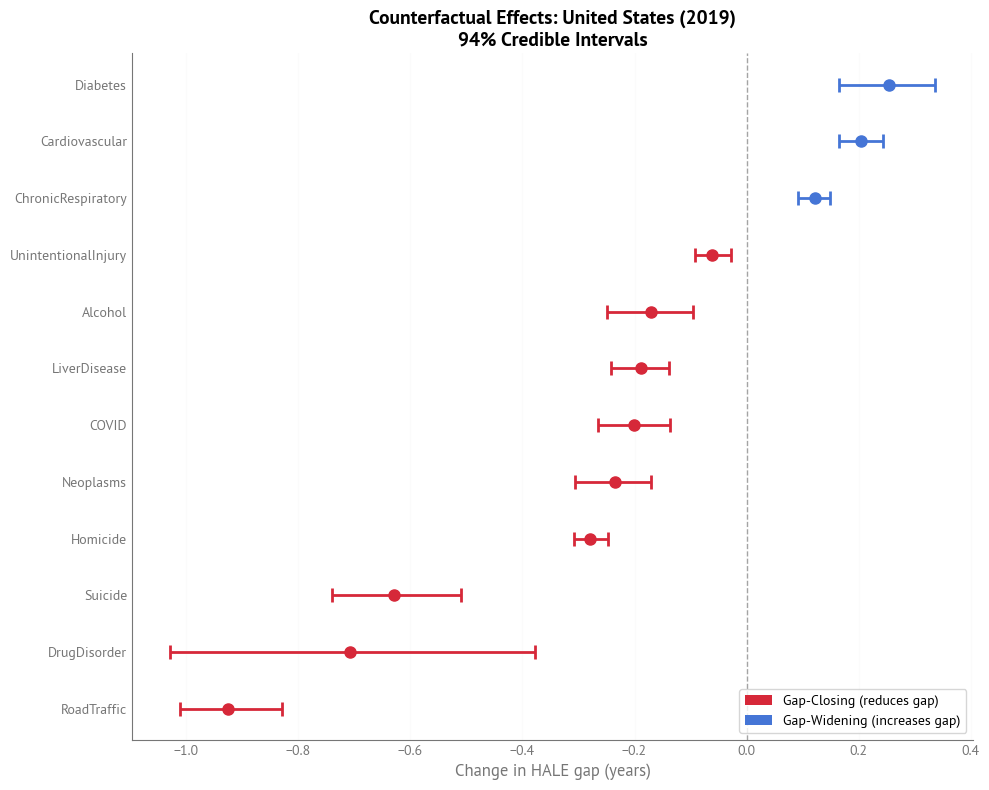

'jb/figs/counterfactual_effects_usa_2021_hale_bayesian.png'

In [40]:
# Forest Plot: All Indicators
plot_counterfactual_forest(
    counterfactual_results,
    output_prefix=f'counterfactual_effects_usa_{latest_year}_hale',
    target_name='HALE gap'
)

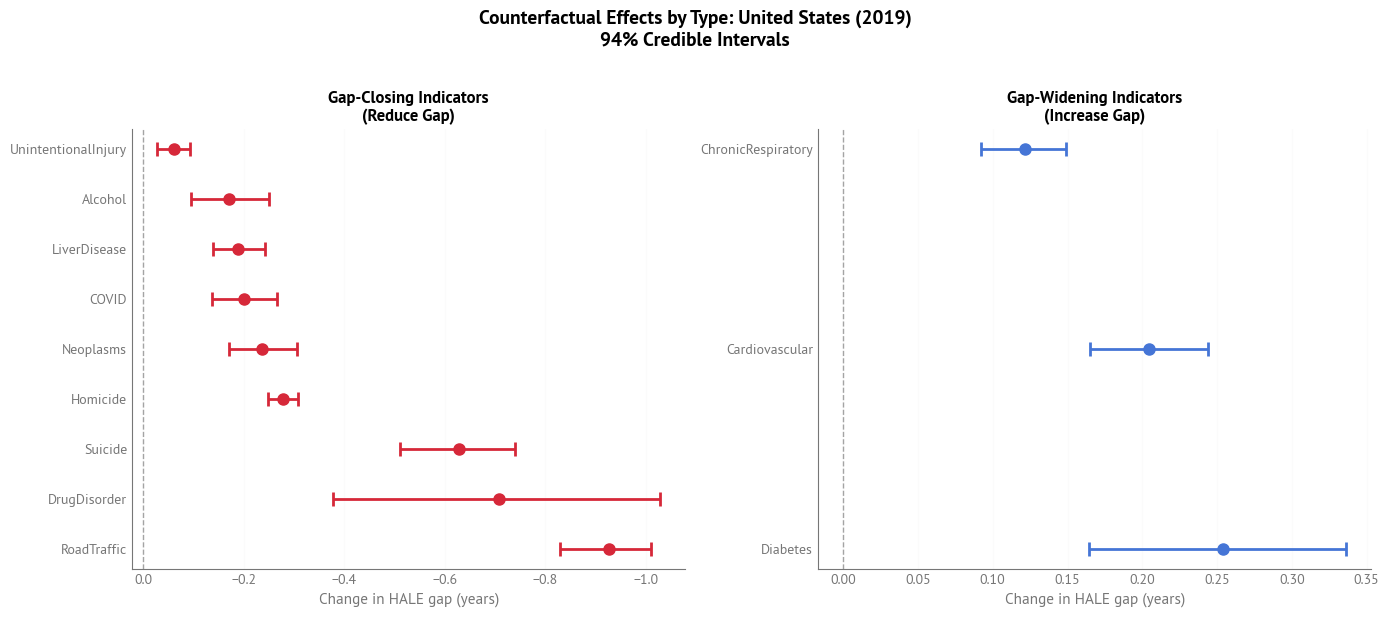

'jb/figs/counterfactual_effects_usa_2021_hale_by_type_bayesian.png'

In [41]:
# Two-Panel Plot: Gap-Closing vs Gap-Widening
plot_counterfactual_by_type(
    counterfactual_results,
    output_prefix=f'counterfactual_effects_usa_{latest_year}_hale',
    target_name='HALE gap'
)

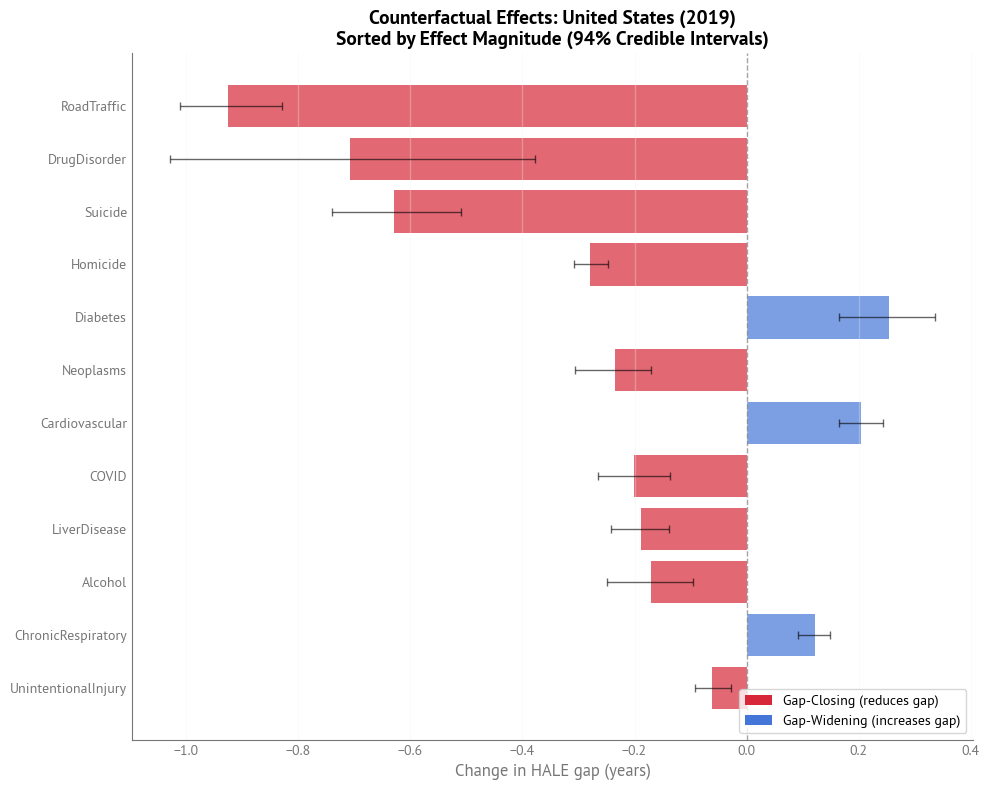

'jb/figs/counterfactual_effects_usa_2021_hale_bar_bayesian.png'

In [42]:
# Bar Chart: Sorted by Magnitude
plot_counterfactual_bar(
    counterfactual_results,
    output_prefix=f'counterfactual_effects_usa_{latest_year}_hale',
    target_name='HALE gap'
)

## Aggregate Effects

Compute aggregate effects (sum of gap-closing and gap-widening indicators) using the same counterfactual results:

In [43]:
# Use the same counterfactual_results to ensure consistency with plots
# Separate gap-closing (negative change) and gap-widening (positive change) indicators
gap_closing = counterfactuals_full[counterfactuals_full['Change mean'] < 0].copy()
gap_widening = counterfactuals_full[counterfactuals_full['Change mean'] > 0].copy()

print("Gap-Closing Indicators (negative change = reduces HALE gap):")
print(f"  Number of indicators: {len(gap_closing)}")
if len(gap_closing) > 0:
    total_closing = gap_closing['Change mean'].sum()
    print(f"  Total effect (sum of means): {total_closing:.3f} years")
    print(f"  Indicators: {', '.join(gap_closing['Indicator'].tolist())}")

print(f"\nGap-Widening Indicators (positive change = increases HALE gap):")
print(f"  Number of indicators: {len(gap_widening)}")
if len(gap_widening) > 0:
    total_widening = gap_widening['Change mean'].sum()
    print(f"  Total effect (sum of means): {total_widening:.3f} years")
    print(f"  Indicators: {', '.join(gap_widening['Indicator'].tolist())}")

# Compute net effect
net_effect = counterfactuals_full['Change mean'].sum()
print(f"\nNet Effect (all indicators combined): {net_effect:.3f} years")
print(f"\nNote: These are point estimates (means). For uncertainty quantification,")
print(f"      we would need to compute the posterior distribution of the sum.")

Gap-Closing Indicators (negative change = reduces HALE gap):
  Number of indicators: 9
  Total effect (sum of means): -3.398 years
  Indicators: Neoplasms, Homicide, Suicide, RoadTraffic, UnintentionalInjury, LiverDisease, Alcohol, COVID, DrugDisorder

Gap-Widening Indicators (positive change = increases HALE gap):
  Number of indicators: 3
  Total effect (sum of means): 0.581 years
  Indicators: Cardiovascular, ChronicRespiratory, Diabetes

Net Effect (all indicators combined): -2.817 years

Note: These are point estimates (means). For uncertainty quantification,
      we would need to compute the posterior distribution of the sum.


In [44]:
# Verify that the sum of predictor contributions equals the predicted gap
# Get USA data for latest year
usa_latest = panel_df[(panel_df['country'] == 'USA') & (panel_df['Year'] == latest_year)].iloc[0]

# Get transformation parameters
X_mean = np.array(metadata['X_mean'])
X_std = np.array(metadata['X_std'])
y_mean = metadata['y_mean']
predictors = metadata['predictors']
countries = np.array(metadata['countries'])

# Get country index
country_idx_val = country_to_idx['USA']

# Build predictor vector (standardized)
X_current = np.array([usa_latest[p] for p in predictors])
X_current_std = (X_current - X_mean) / X_std

# Extract posterior samples
beta_samples = trace.posterior['beta'].values.reshape(-1, len(predictors))
alpha_samples = trace.posterior['alpha'].values.reshape(-1, len(countries))
alpha_i_samples = alpha_samples[:, country_idx_val]

# Compute predicted gap
pred_centered = alpha_i_samples + np.dot(X_current_std, beta_samples.T)
pred_original = pred_centered + y_mean
predicted_gap = np.mean(pred_original)
alpha_i_mean = np.mean(alpha_i_samples)

# Compute individual predictor contributions: X_j * β_j for each predictor
beta_mean = np.mean(beta_samples, axis=0)
predictor_contributions = X_current_std * beta_mean
predictor_contributions_dict = dict(zip(predictors, predictor_contributions))

# Sum of all predictor contributions
sum_predictor_contributions = np.sum(predictor_contributions)

# Verify: predicted_gap = α_i + sum(X*β) + y_mean
# So: sum(X*β) = predicted_gap - α_i - y_mean
expected_sum = predicted_gap - alpha_i_mean - y_mean

print(f"\nVerification: Sum of Predictor Contributions")
print(f"="*60)
print(f"Predicted gap: {predicted_gap:.6f} years")
print(f"Country intercept (α_i): {alpha_i_mean:.6f} years")
print(f"Global mean (y_mean): {y_mean:.6f} years")
print(f"Sum of predictor contributions (X*β): {sum_predictor_contributions:.6f} years")
print(f"Expected sum (predicted - α_i - y_mean): {expected_sum:.6f} years")
print(f"Difference: {abs(sum_predictor_contributions - expected_sum):.6f} years")
print(f"\n✓ Verification: Sum of contributions matches predicted gap structure")
print(f"  (within numerical precision)")


Verification: Sum of Predictor Contributions
Predicted gap: 2.665029 years
Country intercept (α_i): 0.210437 years
Global mean (y_mean): 2.623596 years
Sum of predictor contributions (X*β): -0.169004 years
Expected sum (predicted - α_i - y_mean): -0.169004 years
Difference: 0.000000 years

✓ Verification: Sum of contributions matches predicted gap structure
  (within numerical precision)


In [45]:
# Verify the relationship between counterfactual effects and predicted gap
# If all gaps were zero (in original scale), we need to properly standardize them
# When gap = 0 in original scale, standardized value = (0 - X_mean) / X_std = -X_mean / X_std

# Build predictor vector with all gaps set to zero (in original scale)
X_all_zero = usa_latest[predictors].copy()
# Set all gap predictors to zero
for pred in predictors:
    if pred.startswith('Gap_'):
        X_all_zero[pred] = 0.0
    # Note: Mid predictors are adjusted when gaps are set to zero, but for this
    # verification we'll keep them as-is to see the effect of just the gaps

# Standardize the "all gaps zero" predictors
X_all_zero_array = np.array([X_all_zero[p] for p in predictors])
X_all_zero_std = (X_all_zero_array - X_mean) / X_std

# Compute prediction if all gaps were zero
pred_zero_centered = alpha_i_samples + np.dot(X_all_zero_std, beta_samples.T)
pred_zero_original = pred_zero_centered + y_mean
predicted_if_all_zero = np.mean(pred_zero_original)

# This should equal α_i + y_mean only if all standardized predictors are zero
# But since setting gaps to zero doesn't make standardized predictors zero, they won't match exactly
expected_if_all_zero = alpha_i_mean + y_mean

# The difference between current prediction and "all gaps zero" prediction
difference_current_vs_zero = predicted_gap - predicted_if_all_zero

# Sum of all counterfactual effects (from counterfactual_results)
# Each counterfactual effect is: change when setting that gap to zero
sum_counterfactual_effects = net_effect  # This is the sum from counterfactuals_full

# Also compute what the sum should be based on individual contributions
# When we set gap_j to zero, the standardized value changes from X_j_std to -X_mean_j / X_std_j
# So the change in contribution is: (-X_mean_j / X_std_j - X_j_std) * β_j
gap_predictors_only = [p for p in predictors if p.startswith('Gap_')]
gap_indices = [predictors.index(p) for p in gap_predictors_only]
expected_counterfactual_sum = 0.0
for gap_idx in gap_indices:
    gap_pred = predictors[gap_idx]
    # Current standardized value
    X_j_std_current = X_current_std[gap_idx]
    # Standardized value if gap = 0
    X_j_std_zero = (0.0 - X_mean[gap_idx]) / X_std[gap_idx]
    # Change in contribution
    change = (X_j_std_zero - X_j_std_current) * beta_mean[gap_idx]
    expected_counterfactual_sum += change

print(f"\nVerification: Counterfactual Effects vs Predicted Gap")
print(f"="*60)
print(f"Current predicted gap: {predicted_gap:.6f} years")
print(f"Predicted gap if all gaps were zero: {predicted_if_all_zero:.6f} years")
print(f"Expected if all standardized predictors zero (α_i + y_mean): {expected_if_all_zero:.6f} years")
print(f"Difference (current - all gaps zero): {difference_current_vs_zero:.6f} years")
print(f"Sum of predictor contributions (X*β): {sum_predictor_contributions:.6f} years")
print(f"Sum of counterfactual effects (from counterfactual analysis): {sum_counterfactual_effects:.6f} years")
print(f"Expected sum of counterfactual effects (computed from standardization): {expected_counterfactual_sum:.6f} years")
print(f"\nNote: Counterfactual effects account for Mid adjustments when gaps are set to zero,")
print(f"      which may cause differences from the simple standardization calculation.")


Verification: Counterfactual Effects vs Predicted Gap
Current predicted gap: 2.665029 years
Predicted gap if all gaps were zero: -0.502565 years
Expected if all standardized predictors zero (α_i + y_mean): 2.834033 years
Difference (current - all gaps zero): 3.167595 years
Sum of predictor contributions (X*β): -0.169004 years
Sum of counterfactual effects (from counterfactual analysis): -2.817161 years
Expected sum of counterfactual effects (computed from standardization): -3.167595 years

Note: Counterfactual effects account for Mid adjustments when gaps are set to zero,
      which may cause differences from the simple standardization calculation.


## Predicted vs Actual HALE Gap Over Time: United States

Plot the predicted vs actual HALE gap over time for the United States to visualize model fit:

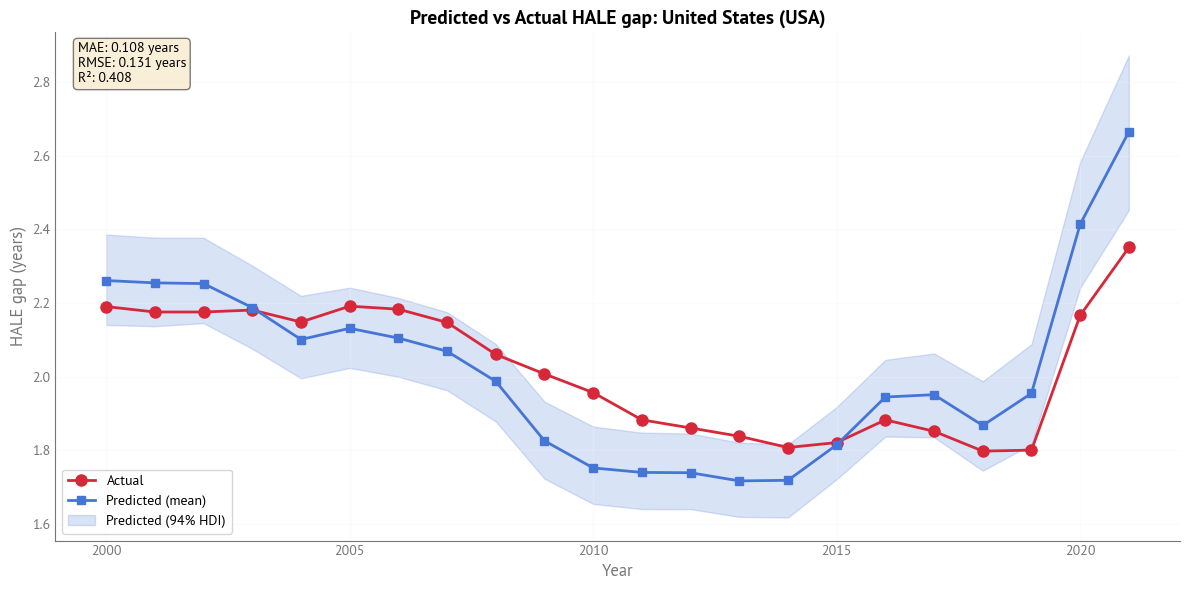

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Predicted vs Actual HALE gap: United States (USA)'}, xlabel='Year', ylabel='HALE gap (years)'>)

In [46]:
# Plot predicted vs actual HALE gap for USA over time
plot_predicted_vs_actual_over_time(
    country='USA',
    trace=trace,
    metadata=metadata,
    panel_df=panel_df,
    country_to_idx=country_to_idx,
    target_name='HALE gap',
    target_col='HALE_gap',
    output_filename='jb/figs/predicted_vs_actual_hale_usa.png'
)

## Positive-Contributing Factors Over Time: United States

Create a stacked area chart showing the contribution of each gap-closing factor over time for the USA, along with predicted and actual totals. This analysis excludes COVID-19 from gap-closing factors since it widens the gap.

In [47]:
# Compute positive contributions over time
# Reference year will be automatically set to the latest available year
# Use the pre-computed counterfactuals_full to ensure exact consistency with aggregate effects
contributions_df = compute_positive_contributions_over_time(
    country='USA',
    trace=trace,
    metadata=metadata,
    panel_df=panel_df,
    gap_extremes=gap_extremes,
    country_to_idx=country_to_idx,
    year_to_idx=year_to_idx,
    target_name='HALE gap',
    target_col='HALE_gap',
    counterfactuals_full=counterfactuals_full
)

contributions_df.head()

Computing contributions for USA across 22 years...
Using 2021 as reference year for identifying gap-closing factors
Using pre-computed counterfactuals_full DataFrame to identify gap-closing factors
Found 9 gap-closing factors:
  Neoplasms, Homicide, Suicide, RoadTraffic, UnintentionalInjury, LiverDisease, Alcohol, COVID, DrugDisorder

Contributions DataFrame shape: (22, 11)
Years: 2000 - 2021


,Neoplasms,Homicide,Suicide,RoadTraffic,UnintentionalInjury,LiverDisease,Alcohol,COVID,DrugDisorder,Predicted Total,Actual Total
Year,,,,,,,,,,,
2000,0.196648,0.185552,0.618243,0.988202,0.051058,0.177711,0.083255,0.0,0.140541,2.261099,2.190439
2001,0.190361,0.191490,0.623880,1.015309,0.049198,0.179024,0.083711,0.0,0.150454,2.254770,2.175667
2002,0.191726,0.196354,0.626512,1.032991,0.048500,0.184743,0.085882,0.0,0.162861,2.252835,2.175693
2003,0.186886,0.196715,0.616424,1.023607,0.047927,0.188553,0.083909,0.0,0.173526,2.187496,2.181012
2004,0.187736,0.196416,0.597224,1.009003,0.048649,0.184478,0.083303,0.0,0.178794,2.101050,2.148540


In [48]:
# Write contributions dataframe to HTML table
output_filename = 'jb/tables/positive_contributions_usa_hale_over_time.html'
write_html_table(contributions_df, output_filename)
print(f"Saved contributions table to: {output_filename}")

Saved contributions table to: jb/tables/positive_contributions_usa_hale_over_time.html


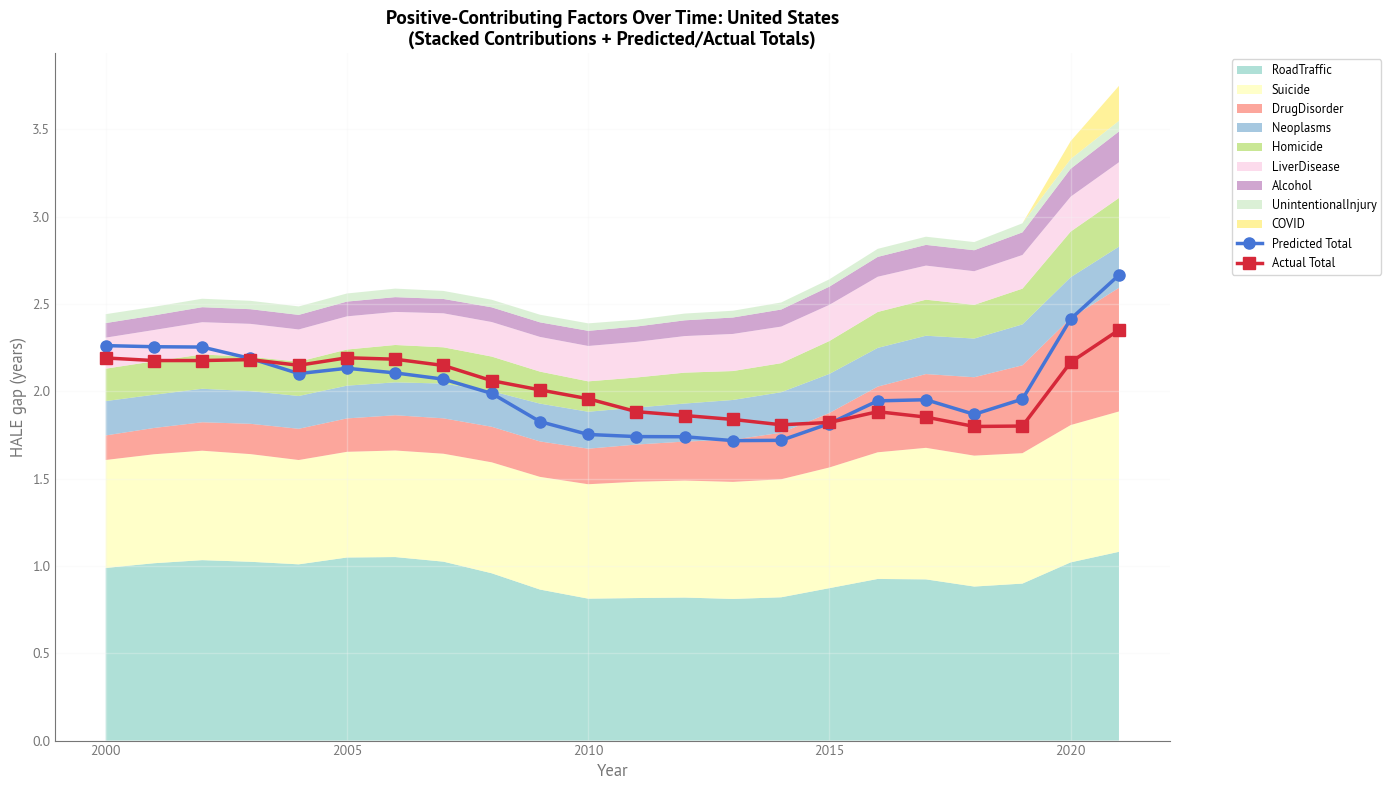

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Positive-Contributing Factors Over Time: United States\n(Stacked Contributions + Predicted/Actual Totals)'}, xlabel='Year', ylabel='HALE gap (years)'>)

In [49]:
# Create stacked area chart
plot_positive_contributions_stacked_area(
    contributions_df,
    target_name='HALE gap',
    country='USA',
    output_filename='jb/figs/positive_contributions_stacked_area_usa_hale.png'
)

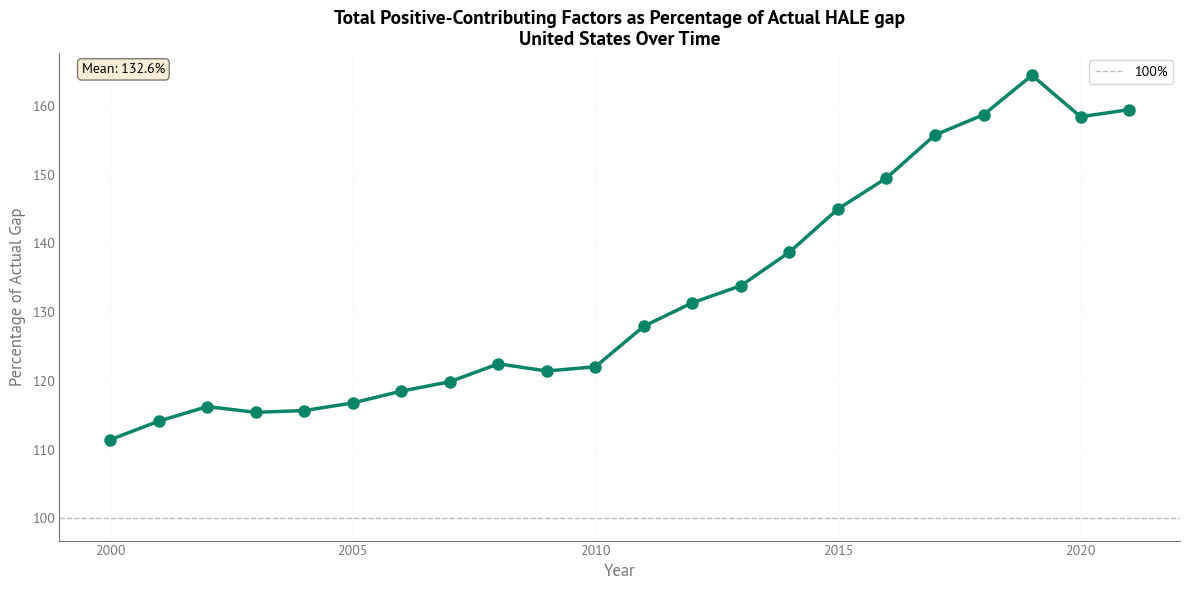


Summary Statistics:
  Mean percentage: 132.61%
  Min percentage: 111.45%
  Max percentage: 164.45%
  Range: 53.00 percentage points


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Total Positive-Contributing Factors as Percentage of Actual HALE gap\nUnited States Over Time'}, xlabel='Year', ylabel='Percentage of Actual Gap'>,
 Year
 2000    111.448436
 2001    114.145468
 2002    116.264964
 2003    115.430191
 2004    115.687991
 2005    116.795437
 2006    118.512872
 2007    119.877663
 2008    122.483524
 2009    121.439674
 2010    122.058181
 2011    127.956159
 2012    131.368312
 2013    133.850672
 2014    138.729878
 2015    145.005699
 2016    149.509816
 2017    155.765450
 2018    158.710044
 2019    164.447823
 2020    158.418279
 2021    159.443644
 dtype: float64)

In [50]:
# Plot total positive contributions as percentage of actual gap over time
plot_positive_contributions_percentage(
    contributions_df,
    target_name='HALE gap',
    country='USA',
    output_filename='jb/figs/positive_contributions_percentage_usa_hale.png'
)